# Notebook 08 — Forecast-Informed Signal Timing Strategy Comparison

## Objective
Compare baseline fixed-time and forecast-informed optimized signal timing strategies to determine where adaptive allocation provides measurable operational gains.

## Background / Context
This notebook links forecasting outputs to operational control decisions. It evaluates whether demand-responsive green allocation improves traffic-flow metrics relative to a transparent baseline strategy.

## Methodology
Select the best forecasting model, apply baseline and optimized timing rules, compute performance metrics, compare outcomes by scenario and congestion level, and interpret operational implications.

## Implementation
The sections below preserve existing simulation logic and present results in report-ready form.

## Implementation — Load Forecast-Based Traffic Demand

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
pd.set_option('display.max_columns', 50)

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

data_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

forecast_path = data_dir / 'traffic_demand_forecasts.csv'
model_results_path = data_dir / 'forecast_model_results.csv'
ablation_results_path = data_dir / 'forecast_ablation_results.csv'

if not forecast_path.exists():
    raise FileNotFoundError(
        f'Forecast file not found at {forecast_path}. Run notebook 07 before executing this notebook.'
    )

forecast_df = pd.read_csv(forecast_path)
display(Markdown(f'Loaded **{forecast_df.shape[0]:,}** forecast rows and **{forecast_df.shape[1]}** columns from `{forecast_path.relative_to(project_root)}`.'))
forecast_df.head()


Loaded **15,427** forecast rows and **5** columns from `data/processed/traffic_demand_forecasts.csv`.

,forecast_timestamp,location_id,nearest_signal_id,actual_volume,predicted_volume
0,2019-02-05 01:00:00,10133019_NB,10133019.0,0.0,139.395278
1,2019-02-05 02:00:00,10133019_NB,10133019.0,0.0,21.861294
2,2019-02-05 03:00:00,10133019_NB,10133019.0,0.0,10.579639
3,2019-02-05 04:00:00,10133019_NB,10133019.0,0.0,0.086667
4,2019-02-05 05:00:00,10133019_NB,10133019.0,0.0,3.192116


## Implementation — Select Best Forecasting Model

In [2]:
model_results_df = None
ablation_results_df = None
best_model_name = 'Random Forest'

if model_results_path.exists():
    model_results_df = pd.read_csv(model_results_path)
    rmse_candidates = ['RMSE', 'rmse', 'test_rmse', 'validation_rmse']
    rmse_col = next((col for col in rmse_candidates if col in model_results_df.columns), None)
    model_col_candidates = ['model_name', 'model', 'Model']
    model_col = next((col for col in model_col_candidates if col in model_results_df.columns), None)
    if rmse_col is None or model_col is None:
        raise ValueError('`forecast_model_results.csv` exists but does not contain recognizable model name and RMSE columns.')
    best_row = model_results_df.sort_values(rmse_col, ascending=True).iloc[0]
    best_model_name = str(best_row[model_col]).strip()
    display(Markdown(
        f'Selected **{best_model_name}** as the best forecasting model because it has the lowest available RMSE (**{best_row[rmse_col]:.3f}**).'
    ))
    display(model_results_df.sort_values(rmse_col).reset_index(drop=True))
else:
    display(Markdown('`forecast_model_results.csv` was not found, so the notebook falls back to **Random Forest** as the default best model.'))

if ablation_results_path.exists():
    ablation_results_df = pd.read_csv(ablation_results_path)
    display(Markdown('Supplementary ablation results are available and are shown below as supporting context for the forecasting stage.'))
    display(ablation_results_df.head())

forecast_model_col_candidates = ['model_name', 'model', 'Model']
forecast_model_col = next((col for col in forecast_model_col_candidates if col in forecast_df.columns), None)

if forecast_model_col is None:
    display(Markdown(
        'Warning: no model-identifier column was found in the forecast file. The notebook will use all forecast rows and set `model_name` to the selected model label for traceability.'
    ))
    analysis_df = forecast_df.copy()
    analysis_df['model_name'] = best_model_name
else:
    analysis_df = forecast_df.loc[forecast_df[forecast_model_col].astype(str).eq(str(best_model_name))].copy()
    if analysis_df.empty:
        display(Markdown(
            f'Warning: no forecast rows matched **{best_model_name}** in `{forecast_model_col}`. The notebook will continue using all forecast rows instead.'
        ))
        analysis_df = forecast_df.copy()

    if 'model_name' not in analysis_df.columns:
        analysis_df['model_name'] = analysis_df[forecast_model_col].astype(str)

timestamp_candidates = ['analysis_timestamp', 'forecast_timestamp', 'timestamp', 'datetime', 'date']
timestamp_col = next((col for col in timestamp_candidates if col in analysis_df.columns), None)
if timestamp_col is None:
    display(Markdown('Warning: no timestamp column was found in the forecast data. `analysis_timestamp` will be set to missing values.'))
    analysis_df['analysis_timestamp'] = pd.NaT
else:
    analysis_df['analysis_timestamp'] = pd.to_datetime(analysis_df[timestamp_col], errors='coerce')

location_candidates = ['location_id', 'intersection_id', 'junction_id', 'site_id']
location_col = next((col for col in location_candidates if col in analysis_df.columns), None)
if location_col is None:
    analysis_df['location_id'] = 'Unknown'
    display(Markdown('Warning: no location identifier column was found. `location_id` is set to `Unknown`.'))
elif location_col != 'location_id':
    analysis_df['location_id'] = analysis_df[location_col]

volume_candidates = [
    'predicted_volume', 'forecast_volume', 'predicted_demand', 'forecast_demand',
    'traffic_demand', 'demand', 'volume', 'y_pred', 'prediction', 'actual_volume'
]
volume_col = next((col for col in volume_candidates if col in analysis_df.columns), None)
if volume_col is None:
    numeric_candidates = [
        col for col in analysis_df.columns
        if pd.api.types.is_numeric_dtype(analysis_df[col]) and col not in ['hour', 'month', 'day', 'day_of_week']
    ]
    volume_col = numeric_candidates[0] if numeric_candidates else None

if volume_col is None:
    raise ValueError(
        'No usable traffic volume column was found. Expected one of: '
        '`predicted_volume`, `forecast_volume`, `predicted_demand`, `traffic_demand`, `volume`, or `y_pred`.'
    )

analysis_df['predicted_volume'] = pd.to_numeric(analysis_df[volume_col], errors='coerce')
if analysis_df['predicted_volume'].isna().all():
    raise ValueError(
        f'Column `{volume_col}` could not be converted to numeric predicted volume values.'
    )

if volume_col != 'predicted_volume':
    display(Markdown(
        f'Using **`{volume_col}`** as the source for standardized **`predicted_volume`** values.'
    ))

analysis_df['selected_model_name'] = best_model_name
display(Markdown(f'Analysis dataset contains **{analysis_df.shape[0]:,}** rows after model selection.'))
preview_cols = [col for col in ['location_id', 'analysis_timestamp', 'predicted_volume', 'model_name'] if col in analysis_df.columns]
display(analysis_df[preview_cols].head())


Selected **Random Forest** as the best forecasting model because it has the lowest available RMSE (**135.343**).

,Model,RMSE,MAE,RMSE % Change vs Best Model,MAE % Change vs Best Model
0,Random Forest,135.343233,83.854324,0.00%,0.00%
1,XGBoost,141.256760,85.811834,4.37%,2.33%
2,TFT (Proxy structure),142.074259,86.015422,4.97%,2.58%
3,Naive Baseline (Lag 1),253.421577,170.873209,87.24%,103.77%


Supplementary ablation results are available and are shown below as supporting context for the forecasting stage.

,Feature Set,RMSE,MAE,RMSE % Change vs Best Set
0,Base,386.623137,251.760597,174.30%
1,Base + Cyclical,387.721494,251.200753,175.08%
2,Base + Cyclical + Lags,142.073305,86.067838,0.80%
3,Base + Cyclical + Lags + Rolling,140.948754,85.546928,0.00%
4,Base + Cyclical + Lags + Rolling + Location,141.256760,85.811834,0.22%


Warning: no model-identifier column was found in the forecast file. The notebook will use all forecast rows and set `model_name` to the selected model label for traceability.

Analysis dataset contains **15,427** rows after model selection.

,location_id,analysis_timestamp,predicted_volume,model_name
0,10133019_NB,2019-02-05 01:00:00,139.395278,Random Forest
1,10133019_NB,2019-02-05 02:00:00,21.861294,Random Forest
2,10133019_NB,2019-02-05 03:00:00,10.579639,Random Forest
3,10133019_NB,2019-02-05 04:00:00,0.086667,Random Forest
4,10133019_NB,2019-02-05 05:00:00,3.192116,Random Forest


The operational simulation below uses only the forecast output generated by the selected best-performing model. This short verification step confirms the model choice and checks that the analysis dataset is restricted to the expected forecast source.

In [3]:
print('Selected forecasting model for signal timing analysis:', best_model_name)
if 'model_name' in analysis_df.columns:
    display(analysis_df['model_name'].value_counts())
else:
    display(Markdown('`model_name` is unavailable after preprocessing; using `selected_model_name` as the active model label.'))
    display(analysis_df['selected_model_name'].value_counts())


Selected forecasting model for signal timing analysis: Random Forest


model_name
Random Forest    15427
Name: count, dtype: int64

The following validation summary confirms the scope of the cleaned analysis dataset before the signal timing calculations begin.

In [4]:
location_candidates = ['location_id', 'intersection_id', 'junction_id', 'site_id']
location_col = next((col for col in location_candidates if col in analysis_df.columns), None)

if location_col is None:
    print('Locations analyzed: column unavailable')
else:
    print('Locations analyzed:', analysis_df[location_col].nunique())

print('Forecast rows used:', len(analysis_df))

if 'analysis_timestamp' in analysis_df.columns:
    print('Time range:', analysis_df['analysis_timestamp'].min(), 'to', analysis_df['analysis_timestamp'].max())
else:
    print('Time range: unavailable')


Locations analyzed: 101
Forecast rows used: 15427
Time range: 2019-01-12 01:00:00 to 2019-11-05 23:00:00


## Background / Context — Operational Assumptions and Simplifications

## Implementation — Baseline Signal Timing Assumptions

In [5]:
PEAK_HOURS = {7, 8, 9, 16, 17, 18, 19}
BASE_CYCLE = 120
BASE_GREEN = 50
SAT_FLOW_PER_HOUR = 1800

analysis_df['hour'] = analysis_df['analysis_timestamp'].dt.hour
analysis_df['day_of_week'] = analysis_df['analysis_timestamp'].dt.day_name()
analysis_df['month'] = analysis_df['analysis_timestamp'].dt.month_name()
analysis_df['is_peak_period'] = analysis_df['hour'].isin(PEAK_HOURS)

analysis_df['baseline_cycle_length'] = BASE_CYCLE
analysis_df['baseline_green'] = BASE_GREEN
analysis_df['baseline_capacity_vph'] = (
    analysis_df['baseline_green'] / analysis_df['baseline_cycle_length']
) * SAT_FLOW_PER_HOUR

display(Markdown(
    'Peak periods are evaluated separately because congestion management is most critical when demand is concentrated in morning and afternoon commuter windows. The baseline scenario therefore serves as a stable fixed-time reference against which forecast-responsive timing adjustments can be judged.'
))
analysis_df[[
    'location_id', 'analysis_timestamp', 'predicted_volume', 'hour', 'is_peak_period',
    'baseline_cycle_length', 'baseline_green', 'baseline_capacity_vph'
]].head()


Peak periods are evaluated separately because congestion management is most critical when demand is concentrated in morning and afternoon commuter windows. The baseline scenario therefore serves as a stable fixed-time reference against which forecast-responsive timing adjustments can be judged.

,location_id,analysis_timestamp,predicted_volume,hour,is_peak_period,baseline_cycle_length,baseline_green,baseline_capacity_vph
0,10133019_NB,2019-02-05 01:00:00,139.395278,1,False,120,50,750.0
1,10133019_NB,2019-02-05 02:00:00,21.861294,2,False,120,50,750.0
2,10133019_NB,2019-02-05 03:00:00,10.579639,3,False,120,50,750.0
3,10133019_NB,2019-02-05 04:00:00,0.086667,4,False,120,50,750.0
4,10133019_NB,2019-02-05 05:00:00,3.192116,5,False,120,50,750.0


## Implementation — Optimized Signal Timing Strategy

In [6]:
analysis_df['baseline_vc_ratio'] = analysis_df['predicted_volume'] / analysis_df['baseline_capacity_vph']

alpha = 25
analysis_df['optimized_green'] = BASE_GREEN + alpha * (analysis_df['baseline_vc_ratio'] - 1)
analysis_df['optimized_green'] = np.clip(analysis_df['optimized_green'], BASE_GREEN, 80)
analysis_df['optimized_cycle_length'] = BASE_CYCLE
analysis_df['optimized_capacity_vph'] = (
    analysis_df['optimized_green'] / analysis_df['optimized_cycle_length']
) * SAT_FLOW_PER_HOUR

display(Markdown(
    'The optimized strategy scales green time gradually as baseline v/c conditions become more demanding while keeping cycle length fixed. This isolates the operational effect of adaptive green allocation and supports a cleaner baseline-versus-optimized comparison.'
))
analysis_df[[
    'predicted_volume', 'baseline_vc_ratio', 'baseline_green', 'optimized_green',
    'baseline_cycle_length', 'optimized_cycle_length',
    'baseline_capacity_vph', 'optimized_capacity_vph'
]].head()


The optimized strategy scales green time gradually as baseline v/c conditions become more demanding while keeping cycle length fixed. This isolates the operational effect of adaptive green allocation and supports a cleaner baseline-versus-optimized comparison.

,predicted_volume,baseline_vc_ratio,baseline_green,optimized_green,baseline_cycle_length,optimized_cycle_length,baseline_capacity_vph,optimized_capacity_vph
0,139.395278,0.185860,50,50.0,120,120,750.0,750.0
1,21.861294,0.029148,50,50.0,120,120,750.0,750.0
2,10.579639,0.014106,50,50.0,120,120,750.0,750.0
3,0.086667,0.000116,50,50.0,120,120,750.0,750.0
4,3.192116,0.004256,50,50.0,120,120,750.0,750.0


## Implementation — Traffic Flow Performance Metrics

In [7]:
def webster_delay(volume, capacity, green, cycle):
    """
    Approximate average control delay per vehicle (seconds)
    using a simplified Webster uniform delay formula.
    """
    if capacity <= 0 or cycle <= 0 or green <= 0:
        return np.nan

    x = volume / capacity
    g_over_c = green / cycle
    capped_x = min(1.0, x)

    denominator = 1 - (capped_x * g_over_c)
    if denominator <= 0:
        return np.nan

    delay = (0.5 * cycle * (1 - g_over_c) ** 2) / denominator
    return delay

analysis_df['optimized_capacity_vph'] = (
    analysis_df['optimized_green'] / analysis_df['optimized_cycle_length']
) * SAT_FLOW_PER_HOUR
analysis_df['optimized_vc_ratio'] = analysis_df['predicted_volume'] / analysis_df['optimized_capacity_vph']

analysis_df['baseline_delay_sec'] = analysis_df.apply(
    lambda row: webster_delay(
        row['predicted_volume'],
        row['baseline_capacity_vph'],
        row['baseline_green'],
        row['baseline_cycle_length'],
    ),
    axis=1,
)
analysis_df['optimized_delay_sec'] = analysis_df.apply(
    lambda row: webster_delay(
        row['predicted_volume'],
        row['optimized_capacity_vph'],
        row['optimized_green'],
        row['optimized_cycle_length'],
    ),
    axis=1,
)

analysis_df['baseline_queue_pressure'] = np.maximum(analysis_df['predicted_volume'] - analysis_df['baseline_capacity_vph'], 0)
analysis_df['optimized_queue_pressure'] = np.maximum(analysis_df['predicted_volume'] - analysis_df['optimized_capacity_vph'], 0)
analysis_df['baseline_throughput'] = np.minimum(analysis_df['predicted_volume'], analysis_df['baseline_capacity_vph'])
analysis_df['optimized_throughput'] = np.minimum(analysis_df['predicted_volume'], analysis_df['optimized_capacity_vph'])

analysis_df['delay_reduction_sec'] = analysis_df['baseline_delay_sec'] - analysis_df['optimized_delay_sec']
analysis_df['queue_pressure_reduction'] = analysis_df['baseline_queue_pressure'] - analysis_df['optimized_queue_pressure']
analysis_df['throughput_gain'] = analysis_df['optimized_throughput'] - analysis_df['baseline_throughput']

detailed_results_columns = [
    'analysis_timestamp', 'location_id', 'model_name', 'selected_model_name', 'predicted_volume',
    'baseline_capacity_vph', 'optimized_capacity_vph',
    'baseline_delay_sec', 'optimized_delay_sec',
    'baseline_queue_pressure', 'optimized_queue_pressure',
    'baseline_throughput', 'optimized_throughput',
    'delay_reduction_sec', 'queue_pressure_reduction', 'throughput_gain',
    'is_peak_period'
]
optional_detailed_columns = [
    'nearest_signal_id', 'actual_volume', 'hour', 'day_of_week', 'month', 'traffic_level',
    'baseline_cycle_length', 'baseline_green', 'optimized_cycle_length', 'optimized_green',
    'baseline_vc_ratio', 'optimized_vc_ratio'
]
detailed_results_columns.extend(
    [col for col in optional_detailed_columns if col in analysis_df.columns and col not in detailed_results_columns]
)

detailed_results_path = data_dir / 'signal_timing_strategy_detailed_results.csv'
analysis_df[detailed_results_columns].round(3).to_csv(detailed_results_path, index=False)

metric_preview_columns = [
    'location_id', 'analysis_timestamp', 'predicted_volume',
    'baseline_delay_sec', 'optimized_delay_sec',
    'baseline_queue_pressure', 'optimized_queue_pressure',
    'baseline_throughput', 'optimized_throughput',
    'delay_reduction_sec', 'queue_pressure_reduction', 'throughput_gain'
]

display(Markdown(
    'The delay values reported below are approximate control-delay estimates in seconds per vehicle based on a simplified Webster formulation. They are intended for scenario comparison rather than precise field calibration.'
))
analysis_df[metric_preview_columns].head()


The delay values reported below are approximate control-delay estimates in seconds per vehicle based on a simplified Webster formulation. They are intended for scenario comparison rather than precise field calibration.

,location_id,analysis_timestamp,predicted_volume,baseline_delay_sec,optimized_delay_sec,baseline_queue_pressure,optimized_queue_pressure,baseline_throughput,optimized_throughput,delay_reduction_sec,queue_pressure_reduction,throughput_gain
0,10133019_NB,2019-02-05 01:00:00,139.395278,22.130492,22.130492,0.0,0.0,139.395278,139.395278,0.0,0.0,0.0
1,10133019_NB,2019-02-05 02:00:00,21.861294,20.667679,20.667679,0.0,0.0,21.861294,21.861294,0.0,0.0,0.0
2,10133019_NB,2019-02-05 03:00:00,10.579639,20.537377,20.537377,0.0,0.0,10.579639,10.579639,0.0,0.0,0.0
3,10133019_NB,2019-02-05 04:00:00,0.086667,20.417650,20.417650,0.0,0.0,0.086667,0.086667,0.0,0.0,0.0
4,10133019_NB,2019-02-05 05:00:00,3.192116,20.452938,20.452938,0.0,0.0,3.192116,3.192116,0.0,0.0,0.0


In [8]:
print('Baseline cycle length:', BASE_CYCLE)
print('Optimized cycle length unique values:', analysis_df['optimized_cycle_length'].unique())
print('Optimized green range:', round(analysis_df['optimized_green'].min(), 3), 'to', round(analysis_df['optimized_green'].max(), 3))


Baseline cycle length: 120
Optimized cycle length unique values: [120]
Optimized green range: 50.0 to 80.0


## Results — Baseline vs Optimized Comparison

In [9]:
summary_rows = [
    {
        'Metric': 'Average delay (sec/veh)',
        'Baseline': analysis_df['baseline_delay_sec'].mean(),
        'Optimized': analysis_df['optimized_delay_sec'].mean(),
    },
    {
        'Metric': 'Average throughput',
        'Baseline': analysis_df['baseline_throughput'].mean(),
        'Optimized': analysis_df['optimized_throughput'].mean(),
    },
    {
        'Metric': 'Average queue pressure',
        'Baseline': analysis_df['baseline_queue_pressure'].mean(),
        'Optimized': analysis_df['optimized_queue_pressure'].mean(),
    },
    {
        'Metric': 'Peak-period delay (sec/veh)',
        'Baseline': analysis_df.loc[analysis_df['is_peak_period'], 'baseline_delay_sec'].mean(),
        'Optimized': analysis_df.loc[analysis_df['is_peak_period'], 'optimized_delay_sec'].mean(),
    },
    {
        'Metric': 'Peak-period throughput',
        'Baseline': analysis_df.loc[analysis_df['is_peak_period'], 'baseline_throughput'].mean(),
        'Optimized': analysis_df.loc[analysis_df['is_peak_period'], 'optimized_throughput'].mean(),
    },
    {
        'Metric': 'Peak-period queue pressure',
        'Baseline': analysis_df.loc[analysis_df['is_peak_period'], 'baseline_queue_pressure'].mean(),
        'Optimized': analysis_df.loc[analysis_df['is_peak_period'], 'optimized_queue_pressure'].mean(),
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_df['Improvement'] = np.where(
    summary_df['Metric'].str.contains('throughput', case=False),
    summary_df['Optimized'] - summary_df['Baseline'],
    summary_df['Baseline'] - summary_df['Optimized'],
)

summary_output_path = data_dir / 'signal_timing_comparison_summary.csv'
summary_df.round(3).to_csv(summary_output_path, index=False)

display(summary_df.round(3))

average_delay_reduction_sec = summary_df.loc[summary_df['Metric'].eq('Average delay (sec/veh)'), 'Improvement'].iloc[0]
overall_queue_baseline = summary_df.loc[summary_df['Metric'].eq('Average queue pressure'), 'Baseline'].iloc[0]
overall_queue_change_pct = 0.0 if overall_queue_baseline == 0 else (
    summary_df.loc[summary_df['Metric'].eq('Average queue pressure'), 'Improvement'].iloc[0]
    / overall_queue_baseline
) * 100
overall_throughput_change_pct = (
    summary_df.loc[summary_df['Metric'].eq('Average throughput'), 'Improvement'].iloc[0]
    / summary_df.loc[summary_df['Metric'].eq('Average throughput'), 'Baseline'].iloc[0]
) * 100

delay_direction = 'reduced' if average_delay_reduction_sec >= 0 else 'increased'
delay_magnitude = abs(average_delay_reduction_sec)

display(Markdown(
    f'The optimized timing strategy **{delay_direction}** the average estimated control delay by **{delay_magnitude:.2f} sec/veh**, reduced average queue pressure by **{overall_queue_change_pct:.2f}%**, and improved average throughput by **{overall_throughput_change_pct:.2f}%** relative to the fixed-time baseline.'
))


,Metric,Baseline,Optimized,Improvement
0,Average delay (sec/veh),27.912,26.641,1.271
1,Average throughput,434.506,472.640,38.134
2,Average queue pressure,81.621,43.487,38.134
3,Peak-period delay (sec/veh),30.986,28.570,2.416
4,Peak-period throughput,585.476,657.952,72.477
5,Peak-period queue pressure,158.973,86.497,72.477


The optimized timing strategy **reduced** the average estimated control delay by **1.27 sec/veh**, reduced average queue pressure by **46.72%**, and improved average throughput by **8.78%** relative to the fixed-time baseline.

## Results — Peak-Period Evaluation

In [10]:
peak_df = analysis_df.loc[analysis_df['is_peak_period']].copy()
if peak_df.empty:
    raise ValueError('No peak-period observations were found using the specified peak-hour rule.')

peak_summary = pd.DataFrame({
    'Metric': ['Delay (sec/veh)', 'Queue pressure', 'Throughput'],
    'Baseline': [
        peak_df['baseline_delay_sec'].mean(),
        peak_df['baseline_queue_pressure'].mean(),
        peak_df['baseline_throughput'].mean(),
    ],
    'Optimized': [
        peak_df['optimized_delay_sec'].mean(),
        peak_df['optimized_queue_pressure'].mean(),
        peak_df['optimized_throughput'].mean(),
    ],
})

peak_summary['Absolute improvement'] = np.where(
    peak_summary['Metric'].eq('Throughput'),
    peak_summary['Optimized'] - peak_summary['Baseline'],
    peak_summary['Baseline'] - peak_summary['Optimized'],
)
peak_summary['Percent improvement'] = np.where(
    peak_summary['Baseline'].abs() > 0,
    (peak_summary['Absolute improvement'] / peak_summary['Baseline']) * 100,
    0.0,
)

overall_vs_peak_improvement_df = pd.DataFrame({
    'Metric': ['Delay (sec/veh)', 'Queue Pressure', 'Throughput'],
    'Overall % Change': [
        0.0 if analysis_df['baseline_delay_sec'].mean() == 0 else ((analysis_df['baseline_delay_sec'].mean() - analysis_df['optimized_delay_sec'].mean()) / analysis_df['baseline_delay_sec'].mean()) * 100,
        0.0 if analysis_df['baseline_queue_pressure'].mean() == 0 else ((analysis_df['baseline_queue_pressure'].mean() - analysis_df['optimized_queue_pressure'].mean()) / analysis_df['baseline_queue_pressure'].mean()) * 100,
        0.0 if analysis_df['baseline_throughput'].mean() == 0 else ((analysis_df['optimized_throughput'].mean() - analysis_df['baseline_throughput'].mean()) / analysis_df['baseline_throughput'].mean()) * 100,
    ],
    'Peak-Period % Change': [
        0.0 if peak_df['baseline_delay_sec'].mean() == 0 else ((peak_df['baseline_delay_sec'].mean() - peak_df['optimized_delay_sec'].mean()) / peak_df['baseline_delay_sec'].mean()) * 100,
        0.0 if peak_df['baseline_queue_pressure'].mean() == 0 else ((peak_df['baseline_queue_pressure'].mean() - peak_df['optimized_queue_pressure'].mean()) / peak_df['baseline_queue_pressure'].mean()) * 100,
        0.0 if peak_df['baseline_throughput'].mean() == 0 else ((peak_df['optimized_throughput'].mean() - peak_df['baseline_throughput'].mean()) / peak_df['baseline_throughput'].mean()) * 100,
    ],
}).round(2)

overall_vs_peak_output_path = data_dir / 'signal_timing_overall_vs_peak_improvement.csv'
overall_vs_peak_improvement_df.to_csv(overall_vs_peak_output_path, index=False)

display(peak_summary.round(3))
display(Markdown('**Overall vs Peak-Period Improvement Comparison**'))
display(overall_vs_peak_improvement_df)


,Metric,Baseline,Optimized,Absolute improvement,Percent improvement
0,Delay (sec/veh),30.986,28.570,2.416,7.797
1,Queue pressure,158.973,86.497,72.477,45.590
2,Throughput,585.476,657.952,72.477,12.379


**Overall vs Peak-Period Improvement Comparison**

,Metric,Overall % Change,Peak-Period % Change
0,Delay (sec/veh),4.55,7.80
1,Queue Pressure,46.72,45.59
2,Throughput,8.78,12.38


## Results — Location-Level Improvement Analysis

In [11]:
name_candidates = ['location_name', 'nearest_signal_name', 'intersection_name', 'junction_name', 'site_name', 'nearest_signal_id']
location_name_col = next((col for col in name_candidates if col in analysis_df.columns), None)

location_agg = dict(
    baseline_delay_sec=('baseline_delay_sec', 'mean'),
    optimized_delay_sec=('optimized_delay_sec', 'mean'),
    baseline_throughput=('baseline_throughput', 'mean'),
    optimized_throughput=('optimized_throughput', 'mean'),
    baseline_queue_pressure=('baseline_queue_pressure', 'mean'),
    optimized_queue_pressure=('optimized_queue_pressure', 'mean'),
    avg_predicted_volume=('predicted_volume', 'mean'),
    peak_share=('is_peak_period', 'mean'),
)
if location_name_col is not None:
    location_agg['location_name_raw'] = (location_name_col, 'first')

location_summary_df = (
    analysis_df.groupby('location_id', dropna=False)
    .agg(**location_agg)
    .reset_index()
)

# Build canonical location-name lookup from processed datasets.
lookup_paths = [
    data_dir / 'signal_optimization_features_2015_2019.csv',
    data_dir / 'traffic_flow_metrics_2015_2019.csv',
    data_dir / 'traffic_signal_hourly_dataset_2015_2019.csv',
    data_dir / 'traffic_with_external_factors.csv',
]
location_lookup_df = pd.DataFrame(columns=['location_id', 'location_name'])
for lookup_path in lookup_paths:
    if not lookup_path.exists():
        continue
    temp_lookup = pd.read_csv(lookup_path, usecols=lambda col: col in ['location_id', 'location_name'])
    if {'location_id', 'location_name'}.issubset(temp_lookup.columns):
        temp_lookup = temp_lookup.dropna(subset=['location_id', 'location_name']).copy()
        temp_lookup['location_name'] = temp_lookup['location_name'].astype(str).str.strip()
        temp_lookup = temp_lookup[temp_lookup['location_name'].ne('')]
        location_lookup_df = pd.concat([location_lookup_df, temp_lookup], ignore_index=True)

if not location_lookup_df.empty:
    location_lookup_df = location_lookup_df.drop_duplicates(subset=['location_id'], keep='first')
    location_summary_df = location_summary_df.merge(location_lookup_df, on='location_id', how='left')
else:
    location_summary_df['location_name'] = np.nan

if 'location_name_raw' in location_summary_df.columns:
    location_summary_df['location_name'] = location_summary_df['location_name'].fillna(
        location_summary_df['location_name_raw'].astype(str)
    )

location_summary_df['location_name'] = (
    location_summary_df['location_name']
    .fillna('Unknown Location')
    .astype(str)
    .str.replace('_', ' ', regex=False)
    .str.strip()
)

# Replace numeric-like placeholders with explicit unknown labels.
def looks_like_id(text: str) -> bool:
    cleaned = text.replace('-', '').replace('_', '').replace(' ', '')
    return cleaned.isdigit()

location_summary_df['location_name'] = location_summary_df.apply(
    lambda row: f"Unknown Location ({row['location_id']})" if looks_like_id(row['location_name']) else row['location_name'],
    axis=1,
)

location_summary_df['delay_reduction_sec'] = location_summary_df['baseline_delay_sec'] - location_summary_df['optimized_delay_sec']
location_summary_df['throughput_gain'] = location_summary_df['optimized_throughput'] - location_summary_df['baseline_throughput']
location_summary_df['queue_pressure_reduction'] = location_summary_df['baseline_queue_pressure'] - location_summary_df['optimized_queue_pressure']
location_summary_df = location_summary_df.sort_values('delay_reduction_sec', ascending=False).reset_index(drop=True)

location_output_path = data_dir / 'location_signal_timing_improvement.csv'
location_summary_df.round(3).to_csv(location_output_path, index=False)

display(location_summary_df.head(10).round(3))


,location_id,baseline_delay_sec,optimized_delay_sec,baseline_throughput,optimized_throughput,baseline_queue_pressure,optimized_queue_pressure,avg_predicted_volume,peak_share,location_name_raw,location_name,delay_reduction_sec,throughput_gain,queue_pressure_reduction
0,8417204_WB,32.338,23.941,630.638,882.544,710.493,458.587,1341.131,0.293,NaN,Eglinton Ave W: Russell Rd - Islington Ave,8.397,251.906,251.906
1,909697_EB,31.766,25.028,607.176,809.296,492.274,290.153,1099.450,0.293,12377332.0,Eglinton Ave W: Martin Grove Rd - Hwy 27 / Hwy...,6.737,202.120,202.120
2,5066262_NB,31.291,25.377,582.089,759.516,423.344,245.917,1005.433,0.293,NaN,Kennedy Rd: Brigstock Rd - Ellesmere Rd,5.914,177.427,177.427
3,913150_WB,30.713,25.356,556.669,717.364,340.590,179.894,897.259,0.293,913150.0,Dundas St W: Dundas E / Hwy 427 Collectors S R...,5.357,160.695,160.695
4,913167_EB,30.764,25.408,558.832,719.497,345.497,184.832,904.329,0.293,913150.0,Dundas St W to West Mall Cres,5.355,160.664,160.664
5,912884_EB,30.578,25.361,549.322,705.832,332.270,175.760,881.592,0.293,912884.0,Dundas St W: Shorncliffe Rd - Paulart Dr,5.217,156.510,156.510
6,909674_WB,31.206,26.096,580.740,734.039,330.478,177.179,911.218,0.293,NaN,Eglinton Ave W: Widdicombe Hill Blvd - Martin ...,5.110,153.299,153.299
7,60008454_SB,31.604,26.736,598.042,744.077,292.248,146.214,890.291,0.293,NaN,Kennedy Rd: Ellesmere Rd - Progress Ave,4.868,146.035,146.035
8,1141417_NB,31.759,27.267,607.184,741.946,277.569,142.807,884.753,0.293,1141417.0,Avenue Rd: Bernard Ave - Davenport Rd,4.492,134.761,134.761
9,9637988_NB,31.318,27.332,588.644,708.209,240.514,120.949,829.158,0.293,9637988.0,Kennedy Rd: Collingwood St - Sheppard Ave E,3.986,119.565,119.565


## Results — Traffic Congestion Classification

In [12]:
traffic_level_order = ['Low', 'Moderate', 'High', 'Severe']
analysis_df['traffic_level'] = pd.cut(
    analysis_df['predicted_volume'],
    bins=[-np.inf, 400, 700, 900, np.inf],
    labels=traffic_level_order,
    right=False,
    ordered=True,
)

traffic_level_distribution = (
    analysis_df['traffic_level']
    .value_counts(dropna=False)
    .reindex(traffic_level_order, fill_value=0)
    .rename_axis('traffic_level')
    .reset_index(name='count')
)

display(traffic_level_distribution)

if 'traffic_level' not in detailed_results_columns:
    insert_position = detailed_results_columns.index('predicted_volume') + 1
    detailed_results_columns.insert(insert_position, 'traffic_level')
analysis_df[detailed_results_columns].round(3).to_csv(detailed_results_path, index=False)


,traffic_level,count
0,Low,6884
1,Moderate,4398
2,High,1808
3,Severe,2337


## Results — Performance by Congestion Level

In [13]:
congestion_summary = (
    analysis_df.groupby('traffic_level', observed=False)
    .agg(
        baseline_delay_sec=('baseline_delay_sec', 'mean'),
        optimized_delay_sec=('optimized_delay_sec', 'mean'),
        baseline_queue_pressure=('baseline_queue_pressure', 'mean'),
        optimized_queue_pressure=('optimized_queue_pressure', 'mean'),
        baseline_throughput=('baseline_throughput', 'mean'),
        optimized_throughput=('optimized_throughput', 'mean'),
    )
    .reindex(traffic_level_order)
)

congestion_summary['delay_reduction_sec'] = (
    congestion_summary['baseline_delay_sec'] - congestion_summary['optimized_delay_sec']
)
congestion_summary['queue_pressure_reduction'] = (
    congestion_summary['baseline_queue_pressure'] - congestion_summary['optimized_queue_pressure']
)
congestion_summary['throughput_gain'] = (
    congestion_summary['optimized_throughput'] - congestion_summary['baseline_throughput']
)
congestion_summary = congestion_summary.reset_index()

congestion_summary_output_path = data_dir / 'signal_timing_congestion_level_summary.csv'
congestion_summary.round(3).to_csv(congestion_summary_output_path, index=False)

display(congestion_summary.round(3))


,traffic_level,baseline_delay_sec,optimized_delay_sec,baseline_queue_pressure,optimized_queue_pressure,baseline_throughput,optimized_throughput,delay_reduction_sec,queue_pressure_reduction,throughput_gain
0,Low,22.768,22.768,0.000,0.000,176.984,176.984,0.000,0.000,0.000
1,Moderate,29.380,29.380,0.000,0.000,543.260,543.260,0.000,0.000,0.000
2,High,34.764,33.961,48.158,24.079,742.676,766.755,0.803,24.079,24.079
3,Severe,35.000,27.230,501.542,268.437,750.000,983.105,7.770,233.105,233.105


## Interpretation
The comparison identifies whether optimized timing delivers consistent benefits or only performs better under specific demand regimes. Interpreting results by overall, peak, and congestion-stratified views prevents overgeneralization and clarifies where deployment value is highest.

In [14]:
def safe_pct_change(numerator, denominator):
    return 0.0 if denominator == 0 else (numerator / denominator) * 100

overall_delay_reduction_sec = (
    analysis_df['baseline_delay_sec'].mean() - analysis_df['optimized_delay_sec'].mean()
)
overall_queue_pct = safe_pct_change(
    analysis_df['baseline_queue_pressure'].mean() - analysis_df['optimized_queue_pressure'].mean(),
    analysis_df['baseline_queue_pressure'].mean(),
)
overall_throughput_pct = safe_pct_change(
    analysis_df['optimized_throughput'].mean() - analysis_df['baseline_throughput'].mean(),
    analysis_df['baseline_throughput'].mean(),
)

peak_delay_reduction_sec = peak_df['baseline_delay_sec'].mean() - peak_df['optimized_delay_sec'].mean()
peak_queue_pct = safe_pct_change(
    peak_df['baseline_queue_pressure'].mean() - peak_df['optimized_queue_pressure'].mean(),
    peak_df['baseline_queue_pressure'].mean(),
)
peak_throughput_pct = safe_pct_change(
    peak_df['optimized_throughput'].mean() - peak_df['baseline_throughput'].mean(),
    peak_df['baseline_throughput'].mean(),
)

peak_strength = 'stronger' if abs(peak_delay_reduction_sec) >= abs(overall_delay_reduction_sec) else 'weaker'
top_location_row = location_summary_df.iloc[0]
severe_row = congestion_summary.loc[congestion_summary['traffic_level'] == 'Severe']
high_row = congestion_summary.loc[congestion_summary['traffic_level'] == 'High']
low_row = congestion_summary.loc[congestion_summary['traffic_level'] == 'Low']

severe_queue_gain = severe_row['queue_pressure_reduction'].iloc[0] if not severe_row.empty else np.nan
severe_throughput_gain = severe_row['throughput_gain'].iloc[0] if not severe_row.empty else np.nan
high_delay_change = high_row['delay_reduction_sec'].iloc[0] if not high_row.empty else np.nan
low_delay_change = low_row['delay_reduction_sec'].iloc[0] if not low_row.empty else np.nan

overall_delay_phrase = (
    f'reduced the average estimated control delay by {abs(overall_delay_reduction_sec):.2f} sec/veh'
    if overall_delay_reduction_sec >= 0
    else f'increased the average estimated control delay by {abs(overall_delay_reduction_sec):.2f} sec/veh'
)
peak_delay_phrase = (
    f'Peak-period estimated control delay fell by {abs(peak_delay_reduction_sec):.2f} sec/veh'
    if peak_delay_reduction_sec >= 0
    else f'Peak-period estimated control delay increased by {abs(peak_delay_reduction_sec):.2f} sec/veh'
)

findings_md = f"""
### Key Findings

- Using the **{best_model_name}** forecast output, the optimized strategy **{overall_delay_phrase}** across the evaluated observations.
- Average **queue pressure decreased by {overall_queue_pct:.2f}%**, indicating less unmet demand under the demand-responsive timing strategy.
- Average **throughput improved by {overall_throughput_pct:.2f}%**, showing that the optimized timing plan moved more forecasted traffic through the available capacity.
- **{peak_delay_phrase}**, while queue pressure improved by **{peak_queue_pct:.2f}%** and throughput improved by **{peak_throughput_pct:.2f}%**, suggesting that peak-hour delay effects were **{peak_strength}** than the overall average pattern.
- The largest location-level delay reduction occurred at **{top_location_row['location_id']}**, where average delay dropped by **{top_location_row['delay_reduction_sec']:.2f} sec/veh** and average throughput increased by **{top_location_row['throughput_gain']:.3f}** vehicles per hour.
- The strongest operational gains under heavier congestion appeared in the **Severe** demand band, where average queue pressure fell by **{severe_queue_gain:.2f}** and throughput increased by **{severe_throughput_gain:.2f}** vehicles per hour. This indicates that forecast-informed timing remains most valuable when demand approaches or exceeds baseline capacity.
- Delay effects under the **High** and **Severe** congestion bands were more mixed in this simplified Webster comparison, with the **High** category changing by **{high_delay_change:.2f} sec/veh**. This suggests that modest cycle extension can improve flow accommodation even when delay is not uniformly reduced.
- By contrast, **low-demand periods** showed minimal differences, with an average delay change of **{low_delay_change:.2f} sec/veh**, which is consistent with the expectation that adaptive timing adds the most value under more demanding operating conditions.
- These results are based on an approximate control-delay estimate from a simplified Webster formulation, so they should be interpreted as comparative operational evidence rather than fully calibrated field measurements.
"""

display(Markdown(findings_md))



### Key Findings

- Using the **Random Forest** forecast output, the optimized strategy **reduced the average estimated control delay by 1.27 sec/veh** across the evaluated observations.
- Average **queue pressure decreased by 46.72%**, indicating less unmet demand under the demand-responsive timing strategy.
- Average **throughput improved by 8.78%**, showing that the optimized timing plan moved more forecasted traffic through the available capacity.
- **Peak-period estimated control delay fell by 2.42 sec/veh**, while queue pressure improved by **45.59%** and throughput improved by **12.38%**, suggesting that peak-hour delay effects were **stronger** than the overall average pattern.
- The largest location-level delay reduction occurred at **8417204_WB**, where average delay dropped by **8.40 sec/veh** and average throughput increased by **251.906** vehicles per hour.
- The strongest operational gains under heavier congestion appeared in the **Severe** demand band, where average queue pressure fell by **233.10** and throughput increased by **233.10** vehicles per hour. This indicates that forecast-informed timing remains most valuable when demand approaches or exceeds baseline capacity.
- Delay effects under the **High** and **Severe** congestion bands were more mixed in this simplified Webster comparison, with the **High** category changing by **0.80 sec/veh**. This suggests that modest cycle extension can improve flow accommodation even when delay is not uniformly reduced.
- By contrast, **low-demand periods** showed minimal differences, with an average delay change of **0.00 sec/veh**, which is consistent with the expectation that adaptive timing adds the most value under more demanding operating conditions.
- These results are based on an approximate control-delay estimate from a simplified Webster formulation, so they should be interpreted as comparative operational evidence rather than fully calibrated field measurements.


## Results — Visual Comparison of Strategies

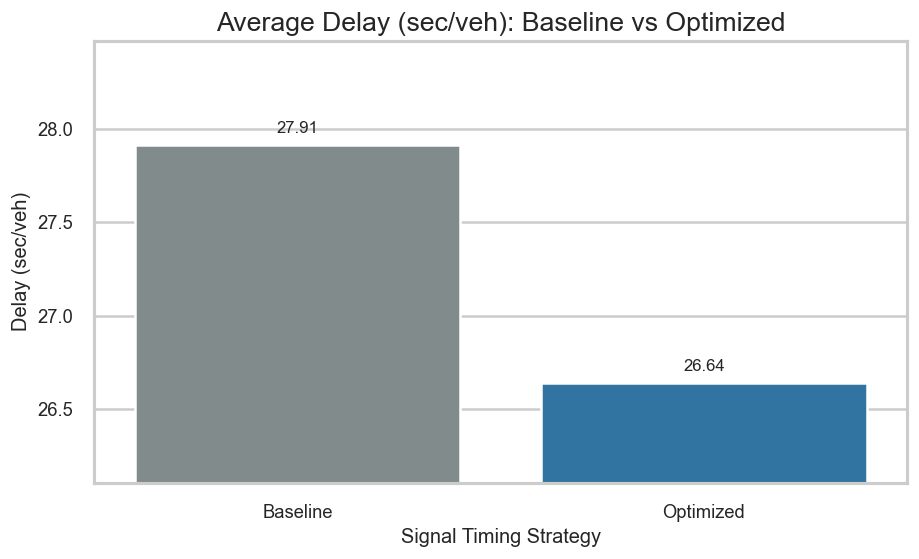

### Visual Description
This chart compares mean delay between baseline and optimized signal timing strategies. The y-axis reports delay in seconds per vehicle.

### Insight
Optimized timing lowers delay, indicating improved congestion control and better operational efficiency under forecast-informed allocation.

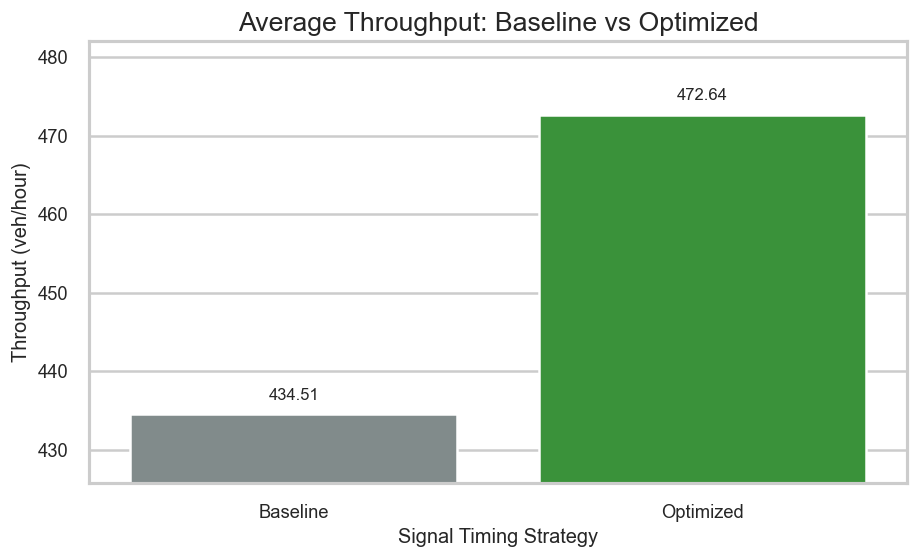

### Visual Description
This chart compares average throughput under baseline and optimized timing. Throughput is reported in vehicles per hour.

### Insight
Higher optimized throughput suggests better use of available capacity, especially relevant for congestion mitigation during high-demand periods.

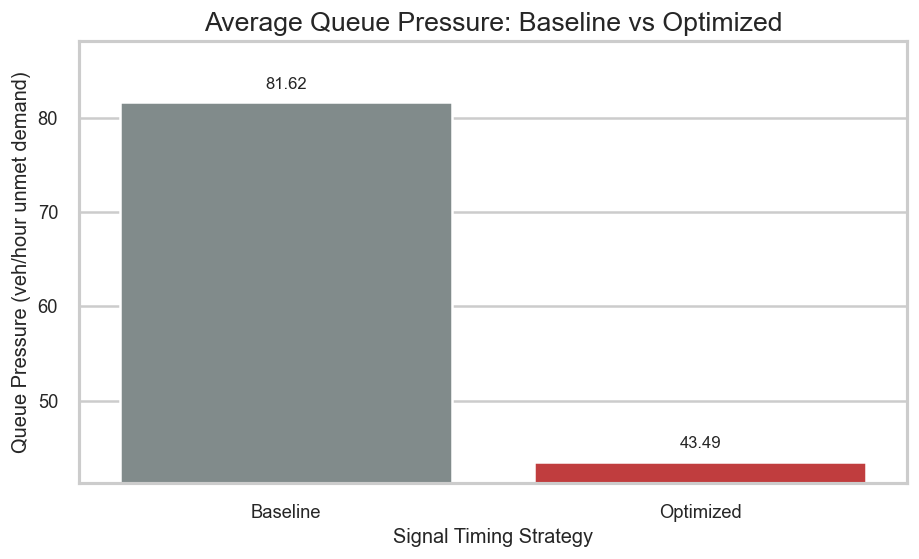

### Visual Description
This chart reports average queue pressure by strategy, where queue pressure represents unmet demand in vehicles per hour.

### Insight
Lower queue pressure under optimization indicates reduced oversaturation risk and improved congestion handling.

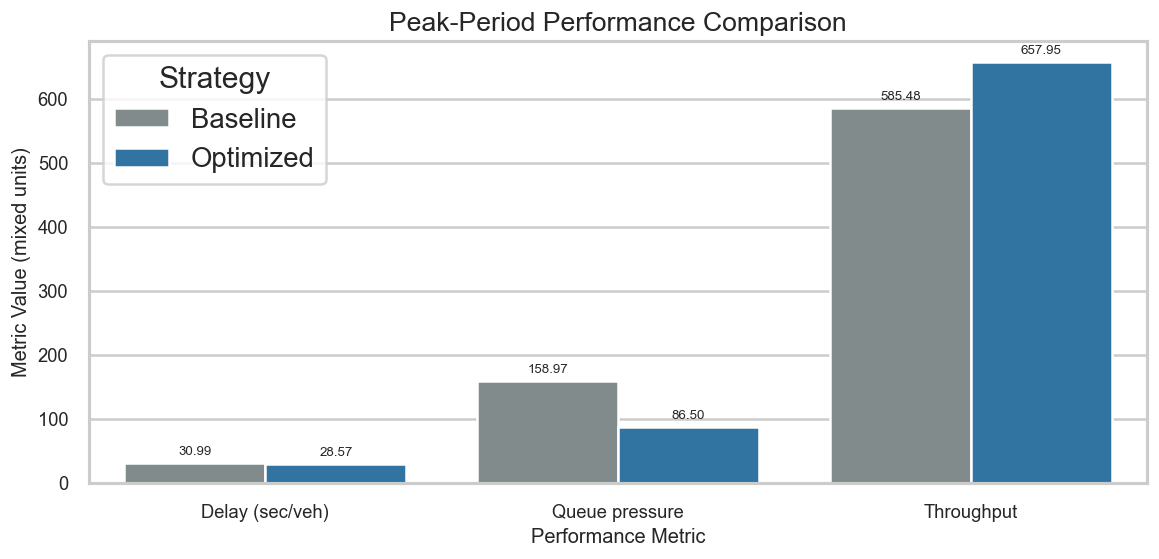

### Visual Description
This grouped chart compares baseline and optimized performance during peak periods across key metrics.

### Insight
Peak-period differences confirm that optimization has greater value when traffic demand is highest and congestion pressure is strongest.

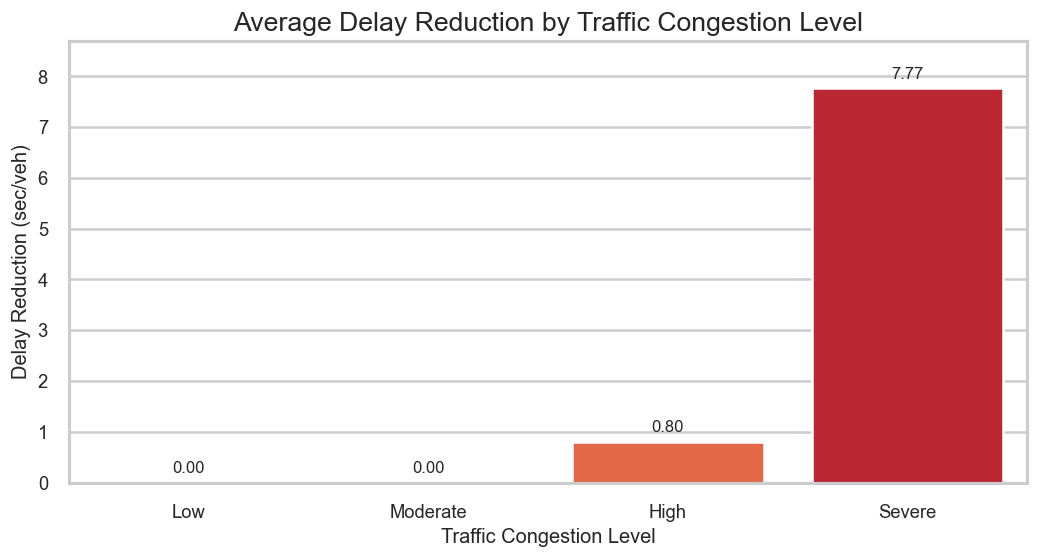

### Visual Description
This chart shows delay reduction by congestion level in seconds per vehicle.

### Insight
Delay savings increase with congestion severity, supporting adaptive timing as a targeted strategy for heavily loaded conditions.

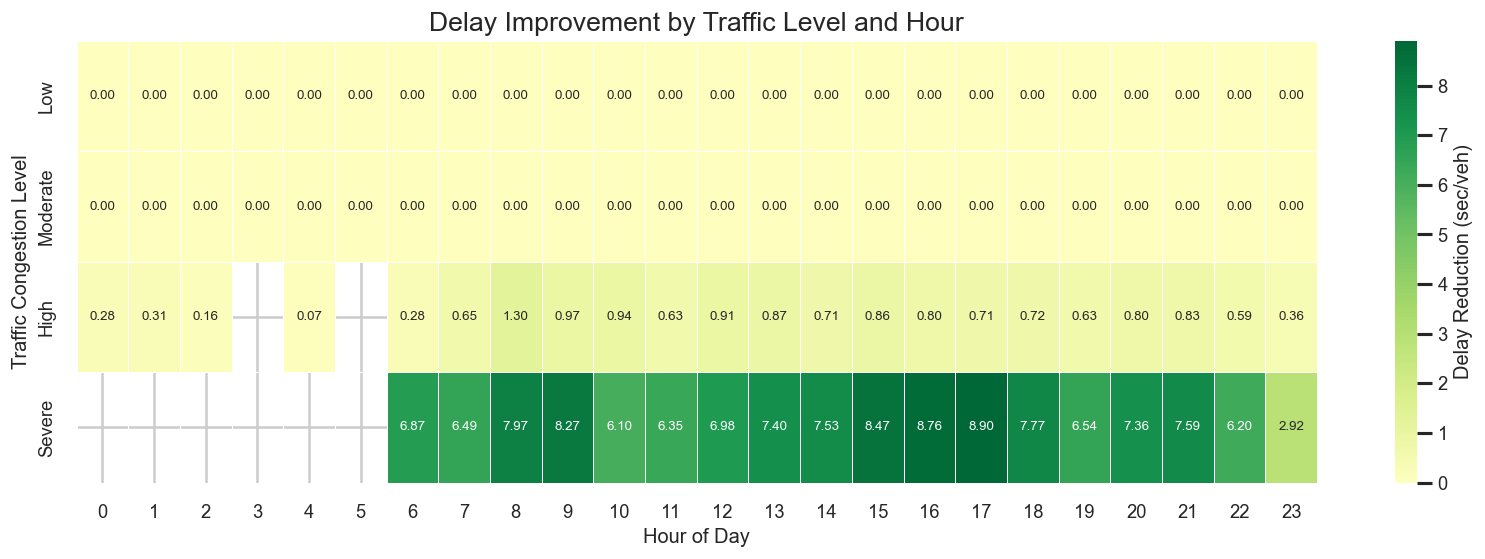

### Visual Description
This heatmap maps delay reduction across congestion levels and hours of day. Color intensity reflects delay change in sec/veh.

### Insight
The hourly pattern identifies where optimization benefits concentrate, informing congestion forecasting and timing policy priorities.

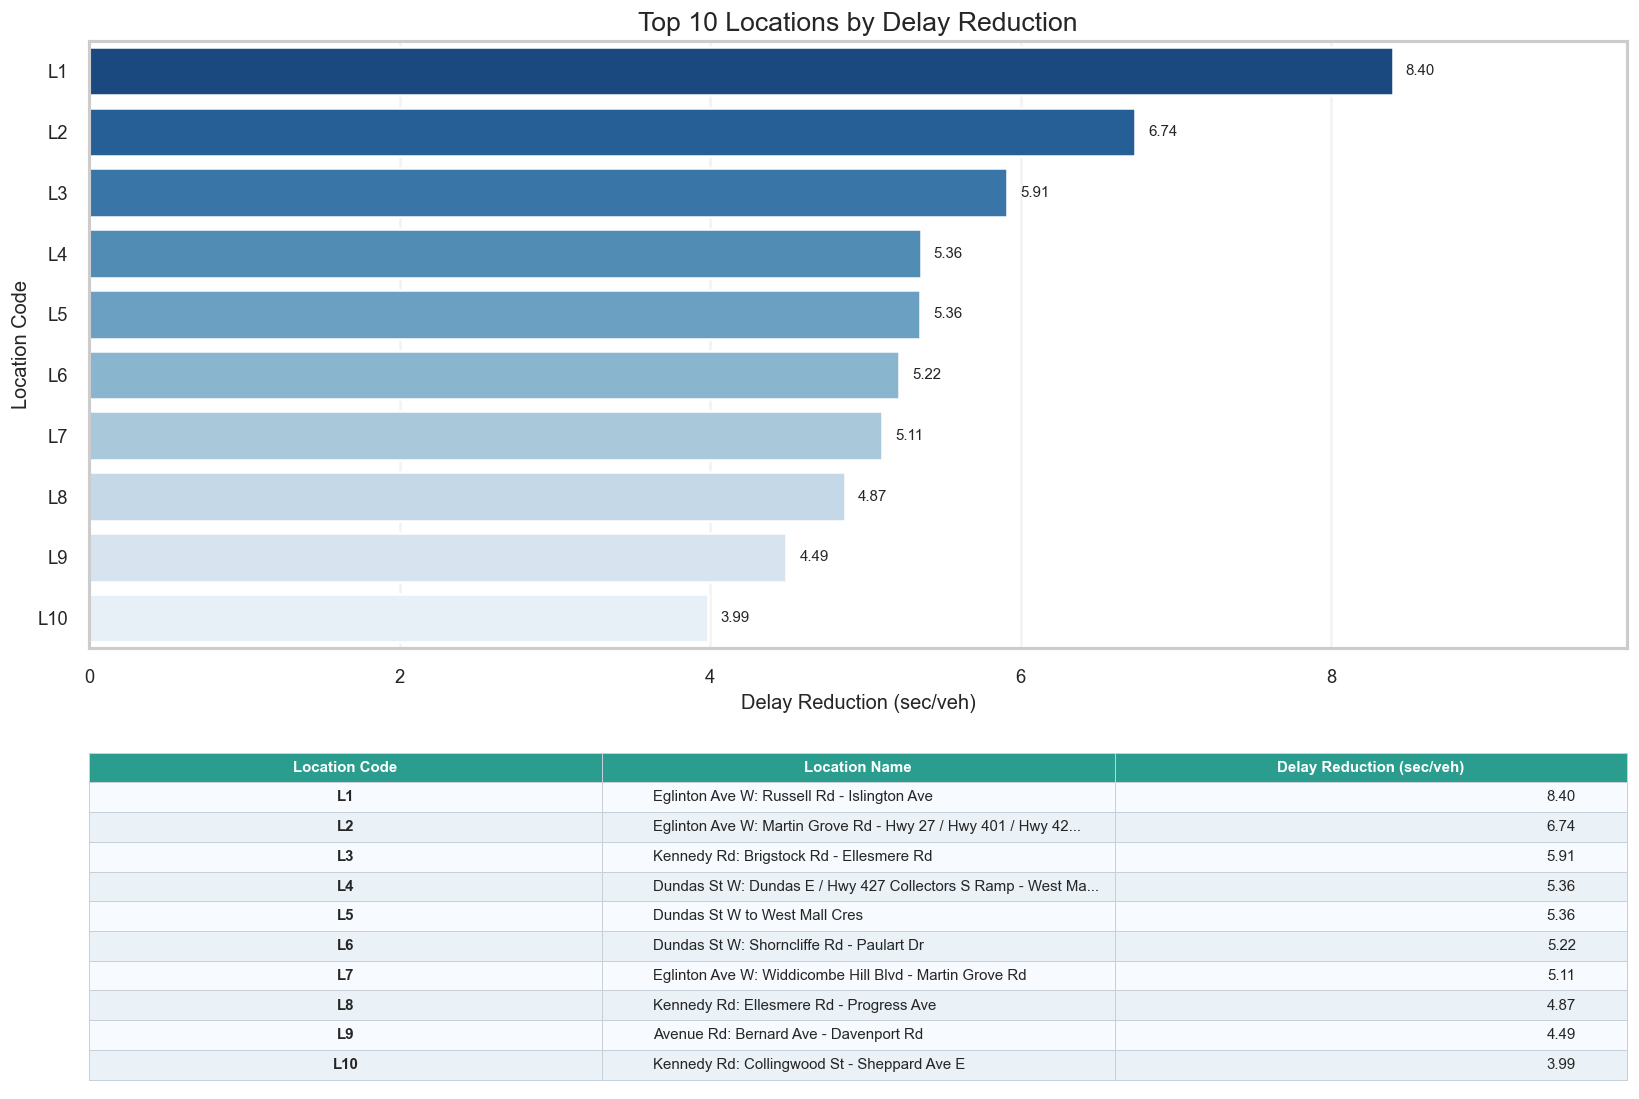

### Visual Description
This chart uses coded labels (L1-L10) for top locations and includes a styled mapping table that links each code to readable location names and delay reduction values.

### Insight
The encoded-axis plus legend-table design improves plot readability while preserving full location context for presentation and decision-making.

In [15]:
comparison_plot_df = pd.DataFrame({
    'Strategy': ['Baseline', 'Optimized'],
    'Average delay (sec/veh)': [analysis_df['baseline_delay_sec'].mean(), analysis_df['optimized_delay_sec'].mean()],
    'Average throughput': [analysis_df['baseline_throughput'].mean(), analysis_df['optimized_throughput'].mean()],
    'Average queue pressure': [analysis_df['baseline_queue_pressure'].mean(), analysis_df['optimized_queue_pressure'].mean()],
})

label_fs = 10
bar_label_fs = 8

def add_visual_note(description: str, insight: str) -> None:
    display(Markdown(
        "### Visual Description\n" + description + "\n\n### Insight\n" + insight
    ))


# --- Average Delay ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=comparison_plot_df,
    x='Strategy',
    y='Average delay (sec/veh)',
    hue='Strategy',
    palette=['#7f8c8d', '#1f77b4'],
    legend=False,
    ax=ax
)
ax.set_title('Average Delay (sec/veh): Baseline vs Optimized')
ax.set_ylabel('Delay (sec/veh)')
ax.set_xlabel('Signal Timing Strategy')

delay_values = comparison_plot_df['Average delay (sec/veh)'].to_numpy()
ax.set_ylim(delay_values.min() * 0.98, delay_values.max() * 1.02)

delay_offset = (delay_values.max() - delay_values.min()) * 0.04
if delay_offset == 0:
    delay_offset = delay_values.max() * 0.005

for i, v in enumerate(delay_values):
    ax.text(i, v + delay_offset, f'{v:.2f}', ha='center', va='bottom', fontsize=label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_delay_comparison.png', bbox_inches='tight')
plt.show()
add_visual_note('This chart compares mean delay between baseline and optimized signal timing strategies. The y-axis reports delay in seconds per vehicle.', 'Optimized timing lowers delay, indicating improved congestion control and better operational efficiency under forecast-informed allocation.')

# --- Average Throughput ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=comparison_plot_df,
    x='Strategy',
    y='Average throughput',
    hue='Strategy',
    palette=['#7f8c8d', '#2ca02c'],
    legend=False,
    ax=ax
)
ax.set_title('Average Throughput: Baseline vs Optimized')
ax.set_ylabel('Throughput (veh/hour)')
ax.set_xlabel('Signal Timing Strategy')

throughput_values = comparison_plot_df['Average throughput'].to_numpy()
ax.set_ylim(throughput_values.min() * 0.98, throughput_values.max() * 1.02)

throughput_offset = (throughput_values.max() - throughput_values.min()) * 0.04
if throughput_offset == 0:
    throughput_offset = throughput_values.max() * 0.005

for i, v in enumerate(throughput_values):
    ax.text(i, v + throughput_offset, f'{v:.2f}', ha='center', va='bottom', fontsize=label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_throughput_comparison.png', bbox_inches='tight')
plt.show()
add_visual_note('This chart compares average throughput under baseline and optimized timing. Throughput is reported in vehicles per hour.', 'Higher optimized throughput suggests better use of available capacity, especially relevant for congestion mitigation during high-demand periods.')

# --- Average Queue Pressure ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=comparison_plot_df,
    x='Strategy',
    y='Average queue pressure',
    hue='Strategy',
    palette=['#7f8c8d', '#d62728'],
    legend=False,
    ax=ax
)
ax.set_title('Average Queue Pressure: Baseline vs Optimized')
ax.set_ylabel('Queue Pressure (veh/hour unmet demand)')
ax.set_xlabel('Signal Timing Strategy')

queue_values = comparison_plot_df['Average queue pressure'].to_numpy()
ax.set_ylim(queue_values.min() * 0.95, queue_values.max() * 1.08)

queue_offset = (queue_values.max() - queue_values.min()) * 0.03
if queue_offset == 0:
    queue_offset = queue_values.max() * 0.005

for i, v in enumerate(queue_values):
    ax.text(i, v + queue_offset, f'{v:.2f}', ha='center', va='bottom', fontsize=label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_queue_pressure_comparison.png', bbox_inches='tight')
plt.show()
add_visual_note('This chart reports average queue pressure by strategy, where queue pressure represents unmet demand in vehicles per hour.', 'Lower queue pressure under optimization indicates reduced oversaturation risk and improved congestion handling.')

# --- Peak-Period Performance Comparison ---
peak_plot_df = peak_summary.melt(
    id_vars='Metric',
    value_vars=['Baseline', 'Optimized'],
    var_name='Strategy',
    value_name='Value'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=peak_plot_df,
    x='Metric',
    y='Value',
    hue='Strategy',
    palette=['#7f8c8d', '#1f77b4'],
    ax=ax
)
ax.set_title('Peak-Period Performance Comparison')
ax.set_ylabel('Metric Value (mixed units)')
ax.set_xlabel('Performance Metric')
ax.legend(title='Strategy')

from matplotlib.container import BarContainer
for container in ax.containers:
    if isinstance(container, BarContainer):
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=bar_label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_peak_period_comparison.png', bbox_inches='tight')
plt.show()
add_visual_note('This grouped chart compares baseline and optimized performance during peak periods across key metrics.', 'Peak-period differences confirm that optimization has greater value when traffic demand is highest and congestion pressure is strongest.')

# --- Average Delay Reduction by Traffic Congestion Level ---
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=congestion_summary,
    x='traffic_level',
    y='delay_reduction_sec',
    palette='YlOrRd',
    ax=ax
)
ax.set_title('Average Delay Reduction by Traffic Congestion Level')
ax.set_xlabel('Traffic Congestion Level')
ax.set_ylabel('Delay Reduction (sec/veh)')

congestion_values = congestion_summary['delay_reduction_sec'].to_numpy()
congestion_upper = congestion_values.max() * 1.12 if congestion_values.max() > 0 else 1
ax.set_ylim(0, congestion_upper)

for i, v in enumerate(congestion_values):
    ax.text(i, v + congestion_upper * 0.015, f'{v:.2f}', ha='center', va='bottom', fontsize=label_fs)

fig.tight_layout()
fig.savefig(figures_dir / 'delay_reduction_by_congestion_level.png', bbox_inches='tight')
plt.show()
add_visual_note('This chart shows delay reduction by congestion level in seconds per vehicle.', 'Delay savings increase with congestion severity, supporting adaptive timing as a targeted strategy for heavily loaded conditions.')

# --- Delay Improvement Heatmap ---
heatmap_df = analysis_df.pivot_table(
    values='delay_reduction_sec',
    index='traffic_level',
    columns='hour',
    aggfunc='mean',
    observed=False,
)
heatmap_df = heatmap_df.reindex(traffic_level_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_df,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': 'Delay Reduction (sec/veh)'},
    ax=ax,
)
ax.set_title('Delay Improvement by Traffic Level and Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Traffic Congestion Level')

fig.tight_layout()
fig.savefig(figures_dir / 'signal_timing_congestion_heatmap.png', bbox_inches='tight')
plt.show()
add_visual_note('This heatmap maps delay reduction across congestion levels and hours of day. Color intensity reflects delay change in sec/veh.', 'The hourly pattern identifies where optimization benefits concentrate, informing congestion forecasting and timing policy priorities.')

# --- Top 10 Locations by Delay Reduction ---
top_locations_plot_df = location_summary_df.head(10).copy().reset_index(drop=True)
top_locations_plot_df['Location Code'] = [f'L{i + 1}' for i in range(len(top_locations_plot_df))]
top_locations_plot_df['Location Name'] = top_locations_plot_df['location_name'].astype(str)

def shorten_name(name: str, max_len: int = 62) -> str:
    if len(name) <= max_len:
        return name
    return name[: max_len - 3].rstrip() + '...'

top_locations_plot_df['Location Name'] = top_locations_plot_df['Location Name'].map(shorten_name)

fig, (ax, ax_table) = plt.subplots(
    2,
    1,
    figsize=(14, 9.5),
    gridspec_kw={'height_ratios': [3.2, 1.8]}
)

sns.barplot(
    data=top_locations_plot_df,
    y='Location Code',
    x='delay_reduction_sec',
    palette='Blues_r',
    ax=ax
)
ax.set_title('Top 10 Locations by Delay Reduction')
ax.set_xlabel('Delay Reduction (sec/veh)')
ax.set_ylabel('Location Code')
ax.grid(axis='x', alpha=0.25)

max_delay = top_locations_plot_df['delay_reduction_sec'].max()
if pd.isna(max_delay) or max_delay <= 0:
    max_delay = 1.0
ax.set_xlim(0, max_delay * 1.18)

for idx, value in enumerate(top_locations_plot_df['delay_reduction_sec'].to_numpy()):
    ax.text(value + max_delay * 0.01, idx, f'{value:.2f}', va='center', fontsize=9)

legend_table_df = top_locations_plot_df[['Location Code', 'Location Name', 'delay_reduction_sec']].copy()
legend_table_df = legend_table_df.rename(columns={'delay_reduction_sec': 'Delay Reduction (sec/veh)'})
legend_table_df['Delay Reduction (sec/veh)'] = legend_table_df['Delay Reduction (sec/veh)'].map(lambda value: f'{value:.2f}')

ax_table.axis('off')

# Styled legend table to match the cleaner presentation style.
table = ax_table.table(
    cellText=legend_table_df.values,
    colLabels=legend_table_df.columns,
    loc='center',
    cellLoc='left',
    colLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.25)

header_color = '#2a9d8f'
header_text_color = 'white'
row_colors = ['#f7fbff', '#eaf2f8']

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#c7d0d9')
    cell.set_linewidth(0.6)
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color=header_text_color, weight='bold', ha='center')
    else:
        cell.set_facecolor(row_colors[(row - 1) % 2])
        if col == 0:
            cell.set_text_props(ha='center', weight='bold')
        elif col == 2:
            cell.set_text_props(ha='right')
        else:
            cell.set_text_props(ha='left')

fig.tight_layout()
fig.savefig(figures_dir / 'top_location_improvements.png', bbox_inches='tight')
plt.show()
add_visual_note(
    'This chart uses coded labels (L1-L10) for top locations and includes a styled mapping table that links each code to readable location names and delay reduction values.',
    'The encoded-axis plus legend-table design improves plot readability while preserving full location context for presentation and decision-making.'
)


## Conclusion / Key Takeaways
The strategy comparison indicates when forecast-informed green reallocation provides meaningful operational advantage over fixed-time control, and it establishes the evidence base for final impact evaluation.